In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import kagglehub
import os

**Dataset from Kaggle**

In [2]:
# Download latest version
path = kagglehub.dataset_download("blurredmachine/are-your-employees-burning-out")
train_csv_path = os.path.join(path, 'train.csv')
test_csv_path = os.path.join(path, 'test.csv')

In [3]:
train = pd.read_csv(train_csv_path)
train = pd.read_csv(train_csv_path)

**Data Overview**

In [4]:
# Data overview for cleaned dataset
overview_df = train.copy()

print("=== SHAPE ===")
print(overview_df.shape)

print("\n=== COLUMN NAMES ===")
print(overview_df.columns.tolist())

print("\n=== DATA TYPES ===")
print(overview_df.dtypes)

print("\n=== MISSING VALUES ===")
print(overview_df.isnull().sum())

print("\n=== SUMMARY STATISTICS ===")
print(overview_df.describe(include="all").T)

print("\n=== UNIQUE VALUES FOR BINARY / LOW-CARDINALITY COLUMNS ===")
for col in overview_df.columns:
    if overview_df[col].nunique() <= 10:
        print(f"\n{col}:")
        print(overview_df[col].value_counts(dropna=False).sort_index())

=== SHAPE ===
(22750, 9)

=== COLUMN NAMES ===
['Employee ID', 'Date of Joining', 'Gender', 'Company Type', 'WFH Setup Available', 'Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate']

=== DATA TYPES ===
Employee ID              object
Date of Joining          object
Gender                   object
Company Type             object
WFH Setup Available      object
Designation             float64
Resource Allocation     float64
Mental Fatigue Score    float64
Burn Rate               float64
dtype: object

=== MISSING VALUES ===
Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

=== SUMMARY STATISTICS ===
                        count unique                       top   freq  \
Employee ID             22750  22750  fffe32003000360033003200      1   


**Data Cleaning**

Drop employee id<br>
Encode Gender, Working From Home, Company Type in training dataset using pandas<br>
Create days since joining and drop date of joining<br>
<br>
days_since_joined was derived from Date of Joining to capture employee tenure in a more usable numeric format. Because all joining dates fall between 2008-01-01 and 2008-12-31, the latest date, 2008-12-31, was used as the reference point. This allows the feature to reflect how long each employee had been with the organization relative to the end of the observed time window.

In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

df_clean = train.copy()

# Drop ID
df_clean = df_clean.drop(columns=["Employee ID"])

# Convert date and create days_since_joined
df_clean["Date of Joining"] = pd.to_datetime(df_clean["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df_clean["days_since_joined"] = (reference_date - df_clean["Date of Joining"]).dt.days
df_clean = df_clean.drop(columns=["Date of Joining"])

#convert designation column and resource allocation from float64 data type to integer data type 
df_clean["Designation"] = df_clean["Designation"].astype(int)

# categorical columns will be one hot encoded during modeling process
cat_cols = [
    "Gender",
    "WFH Setup Available",
    "Company Type"
]

num_cols = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

In [6]:
df_clean

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined
0,Female,Service,No,2,3.0,3.8,0.16,92
1,Male,Service,Yes,1,2.0,5.0,0.36,31
2,Female,Product,Yes,2,NaN,5.8,0.49,296
3,Male,Service,Yes,1,1.0,2.6,0.20,58
4,Female,Service,No,3,7.0,6.9,0.52,160
...,...,...,...,...,...,...,...,...
22745,Female,Service,No,1,3.0,NaN,0.41,1
22746,Female,Product,Yes,3,6.0,6.7,0.59,347
22747,Male,Service,Yes,3,7.0,NaN,0.72,56
22748,Female,Service,No,2,5.0,5.9,0.52,356


**Handling missing values & Feature Engineering & scaling**

In [7]:
dfc = df_clean.copy()

missing_count = dfc.isnull().sum()
missing_pct = (dfc.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct
}).sort_values("missing_percent", ascending=False)

print(missing_summary)

                      missing_count  missing_percent
Mental Fatigue Score           2117             9.31
Resource Allocation            1381             6.07
Burn Rate                      1124             4.94
Gender                            0             0.00
Designation                       0             0.00
WFH Setup Available               0             0.00
Company Type                      0             0.00
days_since_joined                 0             0.00


In [8]:
from scipy.stats import ks_2samp

dfc = df_clean.copy()

# Missingness indicators
dfc["mfs_missing"] = dfc["Mental Fatigue Score"].isna().astype(int)
dfc["ra_missing"] = dfc["Resource Allocation"].isna().astype(int)

In [9]:
# functions to run missingness permutation test
def tvd(p, q):
    p, q = p.align(q, fill_value=0)
    return 0.5 * np.abs(p - q).sum()

def categorical_perm_test(df, group_col, cat_col, n_perm=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    observed_tab = pd.crosstab(df[group_col], df[cat_col], normalize='index')
    observed = tvd(observed_tab.loc[0], observed_tab.loc[1])

    stats = []
    for _ in range(n_perm):
        shuffled = df.copy()
        shuffled[cat_col] = rng.permutation(shuffled[cat_col].values)
        tab = pd.crosstab(shuffled[group_col], shuffled[cat_col], normalize='index')
        stat = tvd(tab.loc[0], tab.loc[1])
        stats.append(stat)

    stats = np.array(stats)
    pval = (np.sum(stats >= observed) + 1) / (n_perm + 1)
    return observed, pval

def ks_perm_test(df, group_col, num_col, n_perm=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    temp = df[[group_col, num_col]].dropna().copy()
    g0 = temp.loc[temp[group_col] == 0, num_col]
    g1 = temp.loc[temp[group_col] == 1, num_col]

    observed = ks_2samp(g0, g1).statistic

    stats = []
    for _ in range(n_perm):
        shuffled = temp.copy()
        shuffled[num_col] = rng.permutation(shuffled[num_col].values)
        g0s = shuffled.loc[shuffled[group_col] == 0, num_col]
        g1s = shuffled.loc[shuffled[group_col] == 1, num_col]
        stats.append(ks_2samp(g0s, g1s).statistic)

    stats = np.array(stats)
    pval = (np.sum(stats >= observed) + 1) / (n_perm + 1)
    return observed, pval

Test statistic<br>
categorical: TVD(total variance distance) : distance measure for categorical distribution<br>
numerical: K-S(Kolmogorov-Smirnov statistic) : difference between numerical distribution<br>
<br>
We used TVD for categorical features because it measures differences in category proportions across the missing and non-missing groups, and we used the K-S statistic for numerical features because it compares the full distributions rather than only their means.

In [10]:
cat_cols = ["Gender","WFH Setup Available", "Company Type"]
num_cols = ["Designation", "days_since_joined", "Mental Fatigue Score", "Burn Rate"]

results = []

for target_missing in ["mfs_missing", "ra_missing"]:
    for col in cat_cols:
        stat, pval = categorical_perm_test(dfc[[target_missing, col]].dropna(), target_missing, col)
        results.append([target_missing, col, "categorical_TVD", stat, pval])

    for col in num_cols:
        stat, pval = ks_perm_test(dfc[[target_missing, col]].dropna(), target_missing, col)
        results.append([target_missing, col, "numeric_KS", stat, pval])

results_df = pd.DataFrame(results, columns=["missing_var", "tested_against", "test", "stat", "p_value"])
results_df = results_df.sort_values(["missing_var", "p_value"])
results_df

C:\Users\alexh\AppData\Local\Temp\ipykernel_14844\2195878564.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  observed = ks_2samp(g0, g1).statistic
C:\Users\alexh\AppData\Local\Temp\ipykernel_14844\2195878564.py:39: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stats.append(ks_2samp(g0s, g1s).statistic)


,missing_var,tested_against,test,stat,p_value
5,mfs_missing,Mental Fatigue Score,numeric_KS,NaN,0.000500
2,mfs_missing,Company Type,categorical_TVD,0.011085,0.311344
0,mfs_missing,Gender,categorical_TVD,0.010365,0.374313
3,mfs_missing,Designation,numeric_KS,0.013300,0.404298
1,mfs_missing,WFH Setup Available,categorical_TVD,0.007997,0.499250
6,mfs_missing,Burn Rate,numeric_KS,0.016924,0.572714
4,mfs_missing,days_since_joined,numeric_KS,0.013029,0.854573
9,ra_missing,Company Type,categorical_TVD,0.021132,0.118941
7,ra_missing,Gender,categorical_TVD,0.009139,0.514243
11,ra_missing,days_since_joined,numeric_KS,0.019523,0.657671


**Main takeaway from the permutation test**<br>
1. Drop Missing Values for Burn Rate<br>
2. Impute Mental Fatigue Score & Resource Allocation with empirical probabilistic imputation & median as baseline<br>
<br>
Mental Fatigue Score: MCAR-consistent Resource Allocation: MCAR-consistent<br>
<br>
Mental fatigue score & resource allocation is closer to MCAR since none of the p-values were small enough to be significant.<br>
<br>
Although, mental fatigue score could be NMAR since workers with extremely high mental fatigue score would be hesitant to share it, we can not test for this with the data.<br>
<br>
For MCAR, empirical probabilistic imputation is the strongest fit. You fill missing values by randomly sampling from the observed values in that same column. Under MCAR this method gives unbiased estimates of the true mean and variance, unlike single-value imputation.

Removed scaling due to it creating noise for tree based models which made it perform worse

In [11]:
from sklearn.preprocessing import StandardScaler

# Drop rows where Burn Rate is null
df_clean = df_clean.dropna(subset=["Burn Rate"]).copy()

# Columns to impute
cols_to_impute = ["Mental Fatigue Score", "Resource Allocation"]

# -----------------------------
# Median-imputed + engineered
# -----------------------------
df_median = df_clean.copy()

for col in cols_to_impute:
    df_median[col] = df_median[col].fillna(df_median[col].median())

# Feature engineering
df_median["Workload Fatigue Interaction"] = df_median["Resource Allocation"] * df_median["Mental Fatigue Score"]
df_median["Fatigue Ratio"] = df_median["Mental Fatigue Score"] / df_median["Resource Allocation"]
df_median["High Workload"] = np.where(
    df_median["Resource Allocation"] > df_median["Resource Allocation"].median(), 1, 0
)
df_median["High Fatigue"] = np.where(
    df_median["Mental Fatigue Score"] > df_median["Mental Fatigue Score"].median(), 1, 0
)
df_median["Stress Index"] = (
    0.7 * df_median["Mental Fatigue Score"] + 0.3 * df_median["Resource Allocation"]
)

df_median["High Stress"] = np.where(df_median["Stress Index"] > df_median["Stress Index"].median(), 1, 0)

df_median["High Burn Rate"] = np.where(df_median["Burn Rate"] > df_median["Burn Rate"].median(), 1, 0)


# -----------------------------
# Empirical probabilistic-imputed + engineered
# -----------------------------
df_prob = df_clean.copy()
rng = np.random.default_rng(42)

for col in cols_to_impute:
    missing_mask = df_prob[col].isna()
    observed_values = df_prob.loc[~missing_mask, col].values
    df_prob.loc[missing_mask, col] = rng.choice(
        observed_values,
        size=missing_mask.sum(),
        replace=True
    )

#data type conversions
df_median["Resource Allocation"] = df_median["Resource Allocation"].astype(int)
df_prob["Resource Allocation"] = df_prob["Resource Allocation"].astype(int)

# Feature engineering
df_prob["Workload Fatigue Interaction"] = df_prob["Resource Allocation"] * df_prob["Mental Fatigue Score"]
df_prob["Fatigue Ratio"] = df_prob["Mental Fatigue Score"] / df_prob["Resource Allocation"]
df_prob["High Workload"] = np.where(
    df_prob["Resource Allocation"] > df_prob["Resource Allocation"].median(), 1, 0
)
df_prob["High Fatigue"] = np.where(
    df_prob["Mental Fatigue Score"] > df_prob["Mental Fatigue Score"].median(), 1, 0
)
df_prob["Stress Index"] = (
    0.7 * df_prob["Mental Fatigue Score"] + 0.3 * df_prob["Resource Allocation"]
)

df_prob["High Stress"] = np.where(df_prob["Stress Index"] > df_prob["Stress Index"].median(), 1, 0)

df_prob["High Burn Rate"] = np.where(df_prob["Burn Rate"] > df_prob["Burn Rate"].median(), 1, 0)

print("Median-imputed + engineered + scaled dataset preview:")
print(df_median.head())

print("\nProbabilistic-imputed + engineered + scaled dataset preview:")
print(df_prob.head())

Median-imputed + engineered + scaled dataset preview:
   Gender Company Type WFH Setup Available  Designation  Resource Allocation  \
0  Female      Service                  No            2                    3   
1    Male      Service                 Yes            1                    2   
2  Female      Product                 Yes            2                    4   
3    Male      Service                 Yes            1                    1   
4  Female      Service                  No            3                    7   

   Mental Fatigue Score  Burn Rate  days_since_joined  \
0                   3.8       0.16                 92   
1                   5.0       0.36                 31   
2                   5.8       0.49                296   
3                   2.6       0.20                 58   
4                   6.9       0.52                160   

   Workload Fatigue Interaction  Fatigue Ratio  High Workload  High Fatigue  \
0                          11.4       1.266

In [12]:
df_median.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue,Stress Index,High Stress,High Burn Rate
0,Female,Service,No,2,3,3.8,0.16,92,11.4,1.266667,0,0,3.56,0,0
1,Male,Service,Yes,1,2,5.0,0.36,31,10.0,2.500000,0,0,4.10,0,0
2,Female,Product,Yes,2,4,5.8,0.49,296,23.2,1.450000,0,0,5.26,0,1
3,Male,Service,Yes,1,1,2.6,0.20,58,2.6,2.600000,0,0,2.12,0,0
4,Female,Service,No,3,7,6.9,0.52,160,48.3,0.985714,1,1,6.93,1,1


In [13]:
df_prob.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue,Stress Index,High Stress,High Burn Rate
0,Female,Service,No,2,3,3.8,0.16,92,11.4,1.266667,0,0,3.56,0,0
1,Male,Service,Yes,1,2,5.0,0.36,31,10.0,2.500000,0,0,4.10,0,0
2,Female,Product,Yes,2,6,5.8,0.49,296,34.8,0.966667,1,0,5.86,1,1
3,Male,Service,Yes,1,1,2.6,0.20,58,2.6,2.600000,0,0,2.12,0,0
4,Female,Service,No,3,7,6.9,0.52,160,48.3,0.985714,1,1,6.93,1,1


In [14]:
df_clean.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined
0,Female,Service,No,2,3.0,3.8,0.16,92
1,Male,Service,Yes,1,2.0,5.0,0.36,31
2,Female,Product,Yes,2,NaN,5.8,0.49,296
3,Male,Service,Yes,1,1.0,2.6,0.20,58
4,Female,Service,No,3,7.0,6.9,0.52,160


**Correlations with Burn Rate**

mental fatigue - burn rate : 0.94<br>
resource allocation - burn rate : 0.86<br>
designation - burn rate : 0.74<br>
days_since_joined - burn rate 0.001

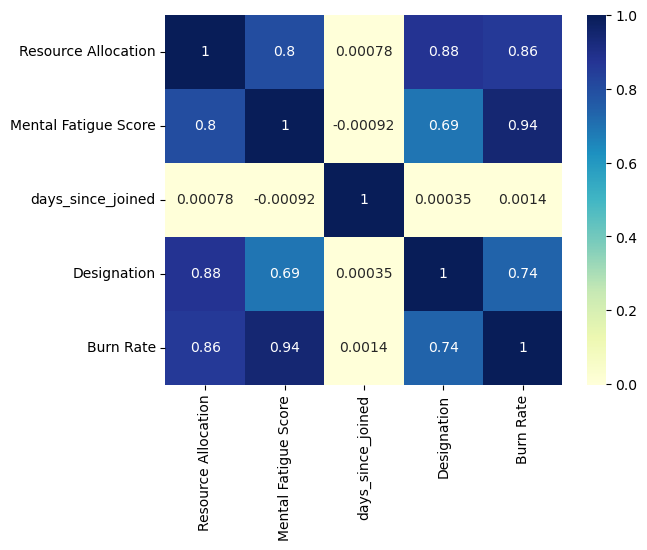

In [15]:
df_corr = df_clean.copy()
numerics = df_corr[["Resource Allocation", "Mental Fatigue Score", "days_since_joined", "Designation", "Burn Rate"]].corr(numeric_only=True)
sns.heatmap(numerics, cmap="YlGnBu", annot=True)
plt.show()

**EDA Analysis**

In [16]:
df_median.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue,Stress Index,High Stress,High Burn Rate
0,Female,Service,No,2,3,3.8,0.16,92,11.4,1.266667,0,0,3.56,0,0
1,Male,Service,Yes,1,2,5.0,0.36,31,10.0,2.500000,0,0,4.10,0,0
2,Female,Product,Yes,2,4,5.8,0.49,296,23.2,1.450000,0,0,5.26,0,1
3,Male,Service,Yes,1,1,2.6,0.20,58,2.6,2.600000,0,0,2.12,0,0
4,Female,Service,No,3,7,6.9,0.52,160,48.3,0.985714,1,1,6.93,1,1


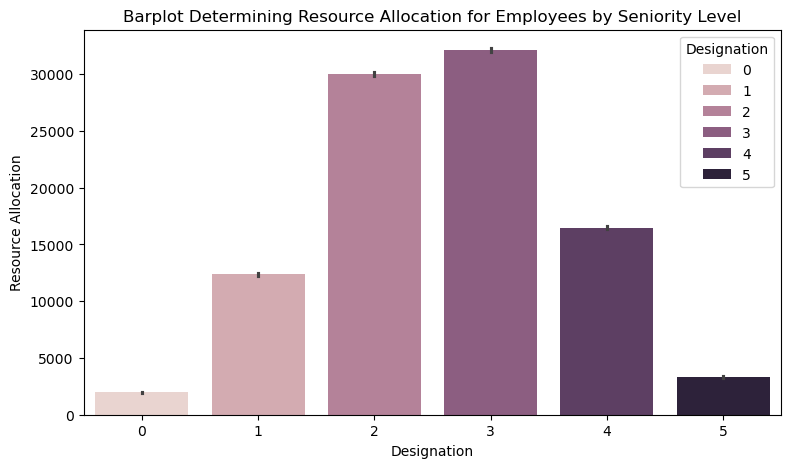

In [17]:
order = [0, 1, 2, 3, 4, 5]

f, x = plt.subplots(1, 1, figsize=(9, 5))
ax = sns.barplot(df_median, x="Designation", y="Resource Allocation", estimator=np.sum, hue="Designation",
                                order=order)
ax.set_title("Barplot Determining Resource Allocation for Employees by Seniority Level");

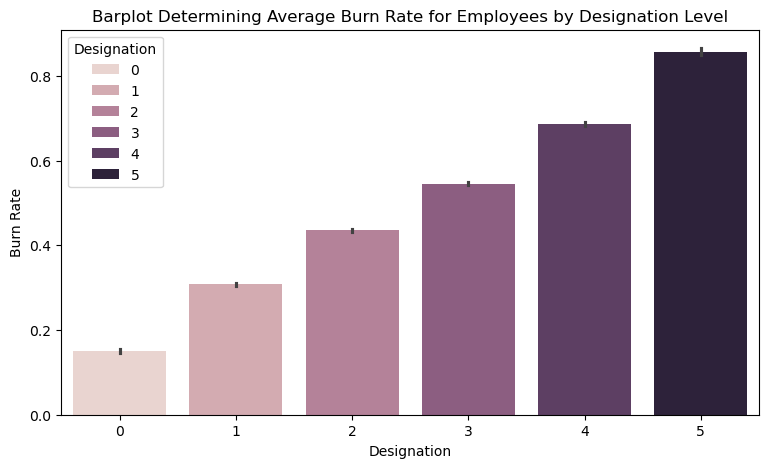

In [18]:
order = [0, 1, 2, 3, 4, 5]

f, x = plt.subplots(1, 1, figsize=(9, 5))
ax = sns.barplot(df_median, x="Designation", y="Burn Rate", estimator=np.mean, hue="Designation",
                                order=order)
ax.set_title("Barplot Determining Average Burn Rate for Employees by Designation Level");

C:\Users\alexh\AppData\Local\Temp\ipykernel_14844\123327205.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"], fontsize=13)
C:\Users\alexh\AppData\Local\Temp\ipykernel_14844\123327205.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)
C:\Users\alexh\AppData\Local\Temp\ipykernel_14844\123327205.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"], fontsize=13)
C:\Users\alexh\AppData\Local\Temp\ipykernel_14844\123327205.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(f

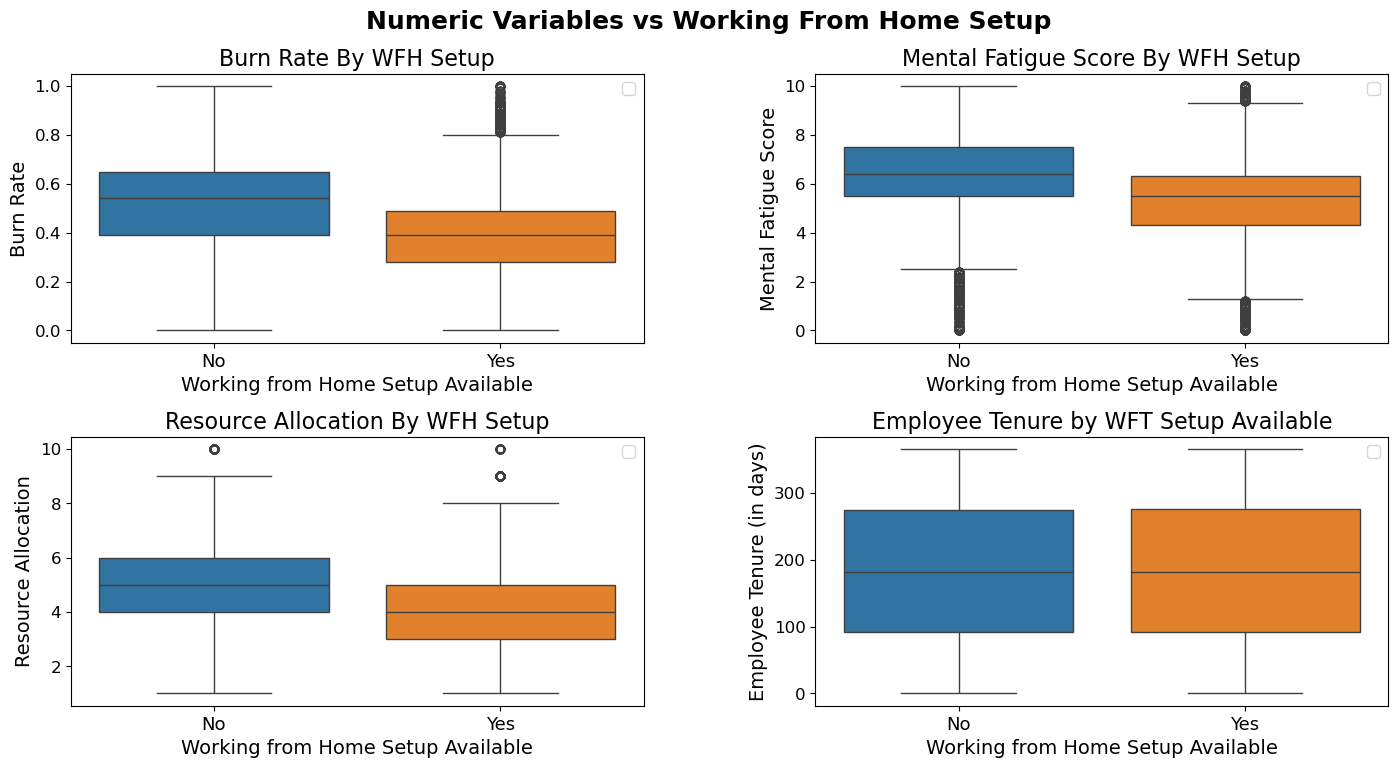

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(17, 8))

sns.boxplot(data=df_median, x="WFH Setup Available", y="Burn Rate", hue="WFH Setup Available", ax=axes[0, 0])
sns.boxplot(data=df_median, x="WFH Setup Available", y="Mental Fatigue Score", hue="WFH Setup Available", ax=axes[0, 1])
sns.boxplot(data=df_median, x="WFH Setup Available", y="Resource Allocation", hue="WFH Setup Available", ax=axes[1, 0])
sns.boxplot(data=df_median, x="WFH Setup Available", y="days_since_joined", hue="WFH Setup Available", ax=axes[1, 1])

axes[0, 0].set_title("Burn Rate By WFH Setup", fontsize=16)
axes[0, 1].set_title("Mental Fatigue Score By WFH Setup", fontsize=16)
axes[1, 0].set_title("Resource Allocation By WFH Setup", fontsize=16)
axes[1, 1].set_title("Employee Tenure by WFT Setup Available", fontsize=16)

axes[1, 1].set_ylabel("Employee Tenure (in days)", fontsize=14)

for ax in axes.flat:  
    ax.set_xlabel("Working from Home Setup Available", fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.set_xticklabels(["No", "Yes"], fontsize=13)
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(fontsize=12)

fig.suptitle("Numeric Variables vs Working From Home Setup", fontsize=18, fontweight="bold", y=0.98)
plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.9)
plt.show()

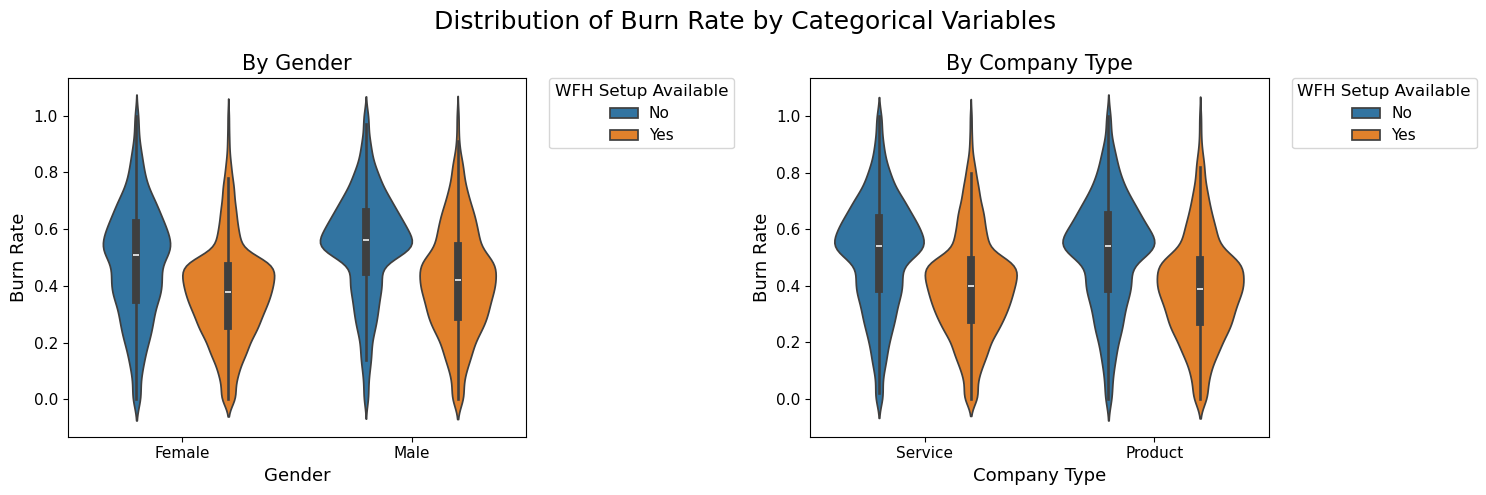

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Distribution of Burn Rate by Categorical Variables", fontsize=18)

sns.violinplot(data=df_median, x="Gender", y="Burn Rate", hue="WFH Setup Available", ax=axes[0])
axes[0].set_title("By Gender", fontsize=15)
axes[0].set_xlabel("Gender", fontsize=13)
axes[0].set_ylabel("Burn Rate", fontsize=13)
axes[0].tick_params(axis='both', labelsize=11)
legend0 = axes[0].legend(title="WFH Setup Available", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
legend0.get_title().set_fontsize(12)
for text in legend0.get_texts():
    text.set_fontsize(11)

sns.violinplot(data=df_median, x="Company Type", y="Burn Rate", hue="WFH Setup Available", ax=axes[1])
axes[1].set_title("By Company Type", fontsize=15)
axes[1].set_xlabel("Company Type", fontsize=13)
axes[1].set_ylabel("Burn Rate", fontsize=13)
axes[1].tick_params(axis='both', labelsize=11)
legend1 = axes[1].legend(title="WFH Setup Available", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
legend1.get_title().set_fontsize(12)
for text in legend1.get_texts():
    text.set_fontsize(11)

plt.tight_layout()
plt.show()

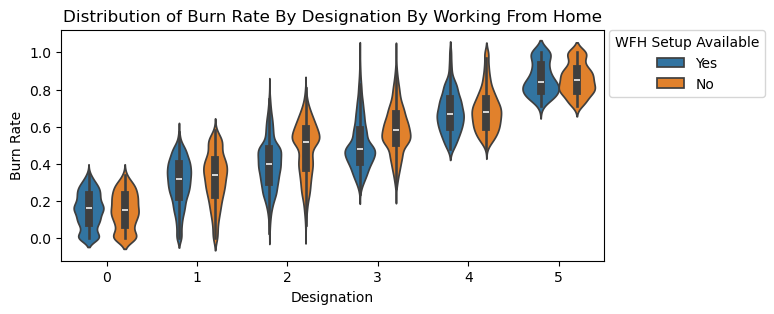

In [21]:
seniority_order = [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(7, 3))
plt.title("Distribution of Burn Rate By Designation By Working From Home")
sns.violinplot(data=df_median, x="Designation", y="Burn Rate", hue="WFH Setup Available", order=seniority_order)
plt.legend(title="WFH Setup Available", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.show()

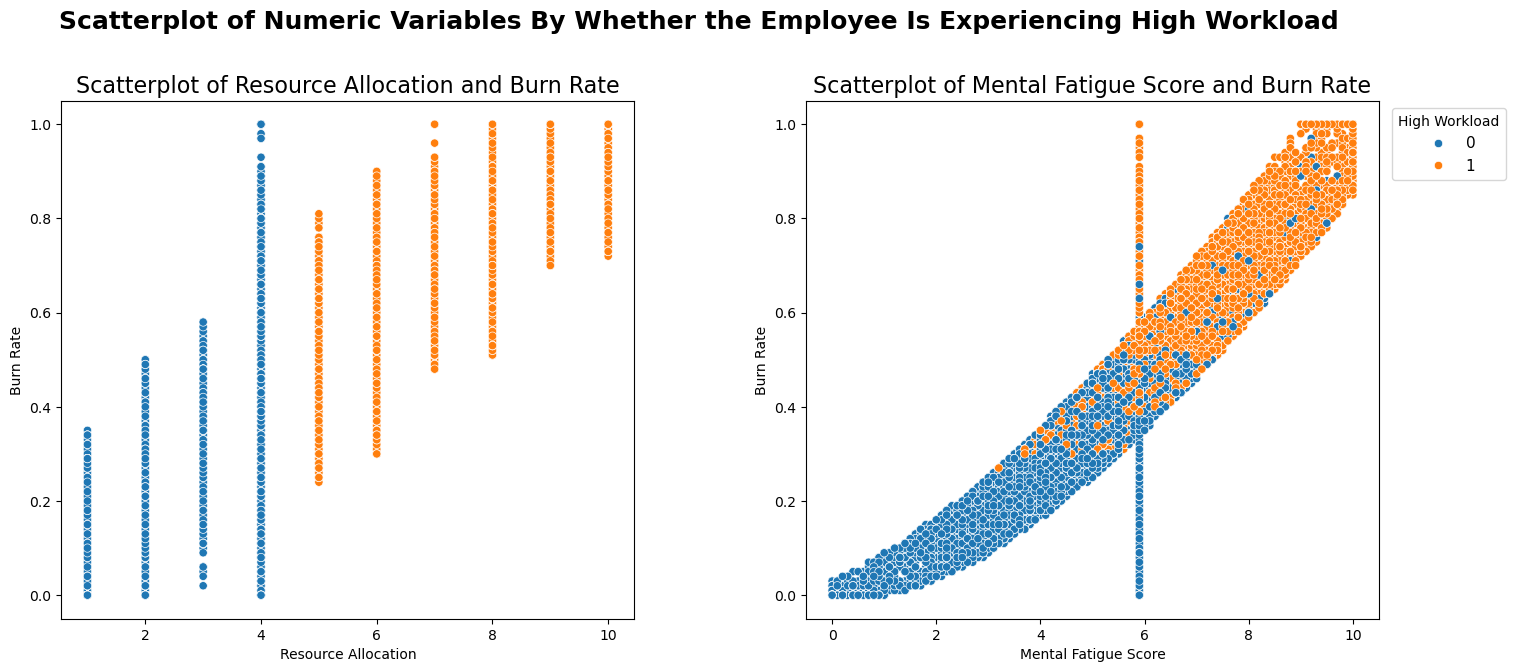

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.scatterplot(data=df_median, x="Resource Allocation", y="Burn Rate", hue="High Workload", ax=axes[0], legend=False)
sns.scatterplot(data=df_median, x="Mental Fatigue Score", y="Burn Rate", hue="High Workload", ax=axes[1], legend=True)

axes[0].set_title("Scatterplot of Resource Allocation and Burn Rate", fontsize=16)
axes[1].set_title("Scatterplot of Mental Fatigue Score and Burn Rate", fontsize=16)

axes[1].legend(title="High Workload", 
               bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=11)

fig.suptitle("Scatterplot of Numeric Variables By Whether the Employee Is Experiencing High Workload", fontsize=18, fontweight="bold", y=0.98)
plt.subplots_adjust(hspace=0.2, wspace=0.3, top=0.85)
plt.show()

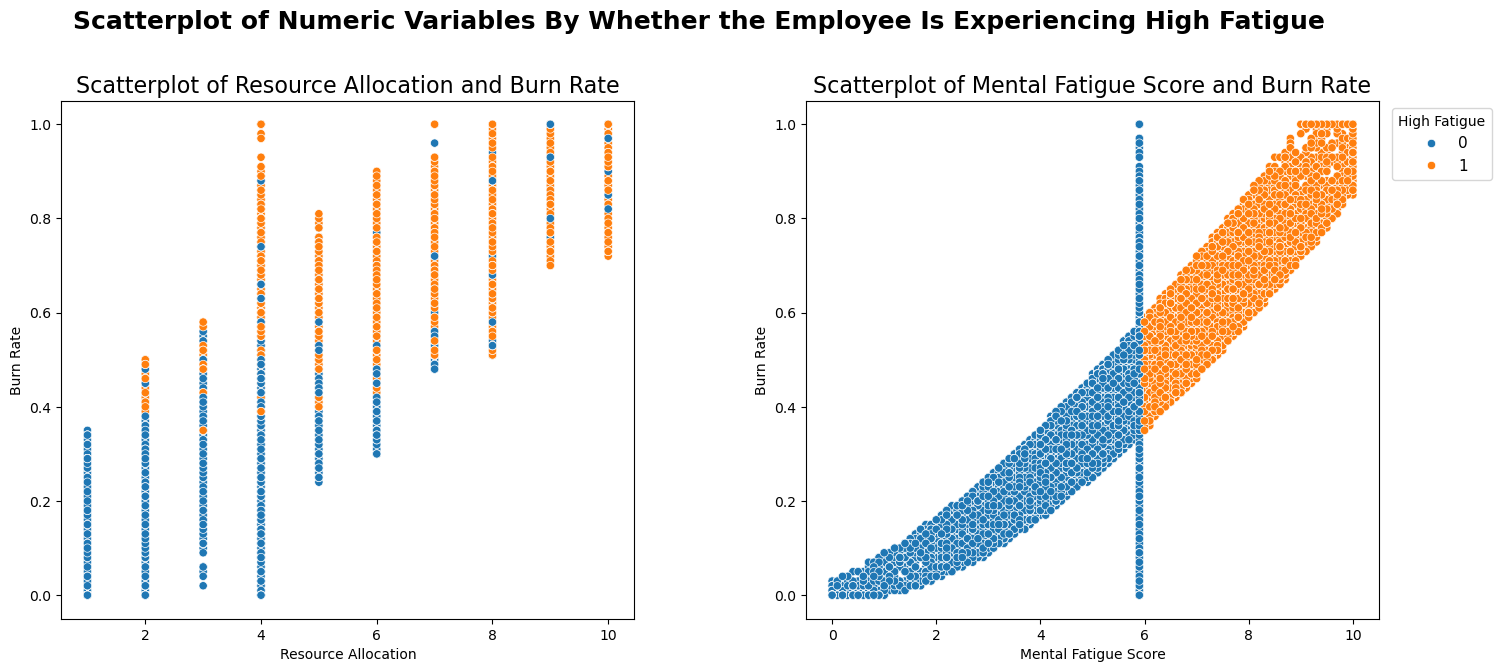

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.scatterplot(data=df_median, x="Resource Allocation", y="Burn Rate", hue="High Fatigue", ax=axes[0], legend=False)
sns.scatterplot(data=df_median, x="Mental Fatigue Score", y="Burn Rate", hue="High Fatigue", ax=axes[1], legend=True)

axes[0].set_title("Scatterplot of Resource Allocation and Burn Rate", fontsize=16)
axes[1].set_title("Scatterplot of Mental Fatigue Score and Burn Rate", fontsize=16)

axes[1].legend(title="High Fatigue", 
               bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=11)

fig.suptitle("Scatterplot of Numeric Variables By Whether the Employee Is Experiencing High Fatigue", fontsize=18, fontweight="bold", y=0.98)
plt.subplots_adjust(hspace=0.2, wspace=0.3, top=0.85)
plt.show()

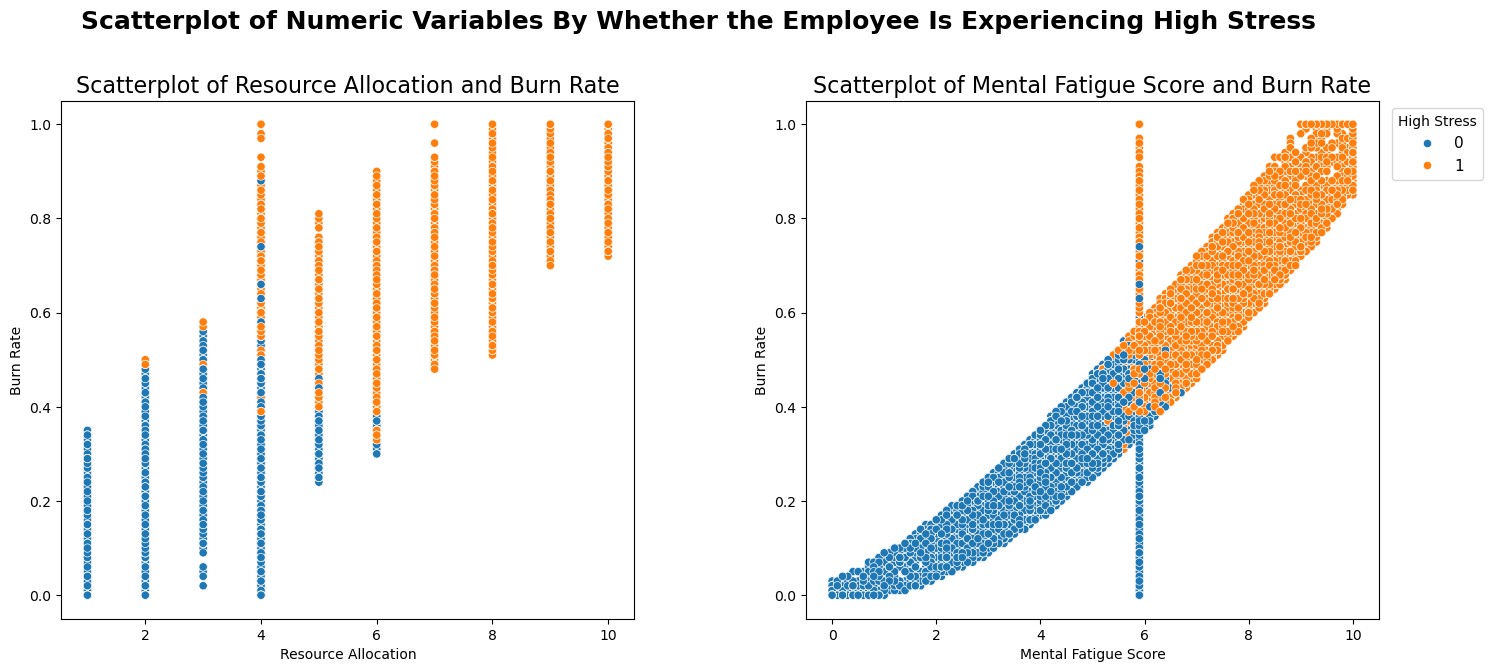

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.scatterplot(data=df_median, x="Resource Allocation", y="Burn Rate", hue="High Stress", ax=axes[0], legend=False)
sns.scatterplot(data=df_median, x="Mental Fatigue Score", y="Burn Rate", hue="High Stress", ax=axes[1], legend=True)

axes[0].set_title("Scatterplot of Resource Allocation and Burn Rate", fontsize=16)
axes[1].set_title("Scatterplot of Mental Fatigue Score and Burn Rate", fontsize=16)

axes[1].legend(title="High Stress", 
               bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=11)

fig.suptitle("Scatterplot of Numeric Variables By Whether the Employee Is Experiencing High Stress", fontsize=18, fontweight="bold", y=0.98)
plt.subplots_adjust(hspace=0.2, wspace=0.3, top=0.85)
plt.show()

**What is the count and percent of total for employees by characterization**
- high stress
- high fatigue 
- high workload

In [25]:
high_stress_counts = df_median["High Stress"].value_counts().reset_index()
high_stress_counts.columns = ["High Stress", "Count"]

high_fatigue_counts = df_median["High Fatigue"].value_counts().reset_index()
high_fatigue_counts.columns = ["High Fatigue", "Count"]

high_workload_counts = df_median["High Workload"].value_counts().reset_index()
high_workload_counts.columns = ["High Workload", "Count"]

high_burn_rate_counts = df_median["High Burn Rate"].value_counts().reset_index()
high_burn_rate_counts.columns = ["High Burn Rate", "Count"]

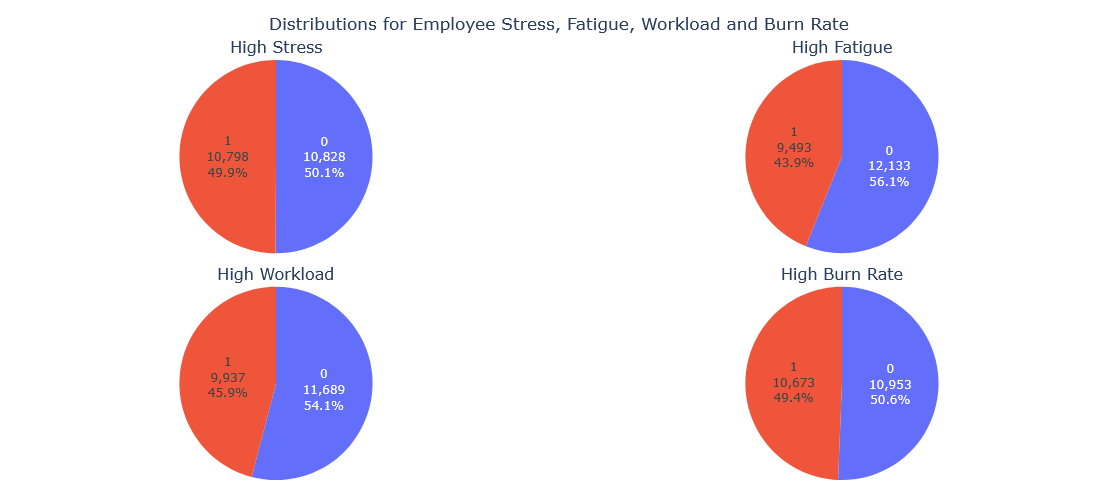

In [26]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

datasets = [
    (high_stress_counts, "High Stress", "High Stress"),
    (high_fatigue_counts, "High Fatigue", "High Fatigue"),
    (high_workload_counts, "High Workload", "High Workload"),
    (high_burn_rate_counts, "High Burn Rate", "High Burn Rate")
]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[d[1] for d in datasets],
    specs=[
        [{"type": "pie"}, {"type": "pie"}],
        [{"type": "pie"}, {"type": "pie"}]
    ],
    horizontal_spacing=0.05,
    vertical_spacing=0.08
)

positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

for (df, col, title), (row, col_pos) in zip(datasets, positions):
    fig.add_trace(
        go.Pie(
            labels=df[col],
            values=df["Count"],
            textinfo="label+percent",
            customdata=df["Count"],
            hovertemplate="<b>%{label}</b><br>Count: %{customdata:,}<br>Percent: %{percent}<extra></extra>",
            texttemplate="%{label}<br>%{customdata:,}<br>%{percent}",
            showlegend=False,
            hole=0.0
        ),
        row=row, col=col_pos
    )

fig.update_layout(
    height=500,
    width=900,   
    margin=dict(t=60, b=20, l=20, r=20),
    title=dict(
        text="Distributions for Employee Stress, Fatigue, Workload and Burn Rate",
        x=0.5,
        xanchor="center",
        xref="paper"
    )
)

fig.show()

**Visualize the trends of high burnout by categorical columns**

In [27]:
pip show ipywidgets

Name: ipywidgets
Version: 7.8.1
Summary: IPython HTML widgets for Jupyter
Home-page: http://ipython.org
Author: IPython Development Team
Author-email: ipython-dev@scipy.org
License: BSD
Location: C:\Users\alexh\anaconda3\Lib\site-packages
Requires: comm, ipython, ipython-genutils, jupyterlab-widgets, traitlets, widgetsnbextension
Required-by: jupyter
Note: you may need to restart the kernel to use updated packages.


In [28]:
df_median_high_burnout = df_median[df_median["High Burn Rate"] == 1]
df_median_high_burnout

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue,Stress Index,High Stress,High Burn Rate
2,Female,Product,Yes,2,4,5.8,0.49,296,23.2,1.450000,0,0,5.26,0,1
4,Female,Service,No,3,7,6.9,0.52,160,48.3,0.985714,1,1,6.93,1,1
6,Female,Service,No,3,6,7.9,0.62,364,47.4,1.316667,1,1,7.33,1,1
8,Female,Service,No,3,6,5.9,0.56,4,35.4,0.983333,1,0,5.93,1,1
9,Female,Product,No,3,6,5.9,0.67,297,35.4,0.983333,1,0,5.93,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22744,Male,Product,No,3,7,6.2,0.54,218,43.4,0.885714,1,1,6.44,1,1
22746,Female,Product,Yes,3,6,6.7,0.59,347,40.2,1.116667,1,1,6.49,1,1
22747,Male,Service,Yes,3,7,5.9,0.72,56,41.3,0.842857,1,0,6.23,1,1
22748,Female,Service,No,2,5,5.9,0.52,356,29.5,1.180000,1,0,5.63,1,1


In [29]:
gender_factors = df_median_high_burnout["Gender"].value_counts().reset_index()
gender_factors.columns = ["Gender", "Count"]

company_type_factors = df_median_high_burnout["Company Type"].value_counts().reset_index()
company_type_factors.columns = ["Company Type", "Count"]

wfh_counts = df_median_high_burnout["WFH Setup Available"].value_counts().reset_index()
wfh_counts.columns = ["WFH Setup Available", "Count"]

designation_counts = df_median_high_burnout["Designation"].value_counts().reset_index()
designation_counts.columns = ["Designation", "Count"]

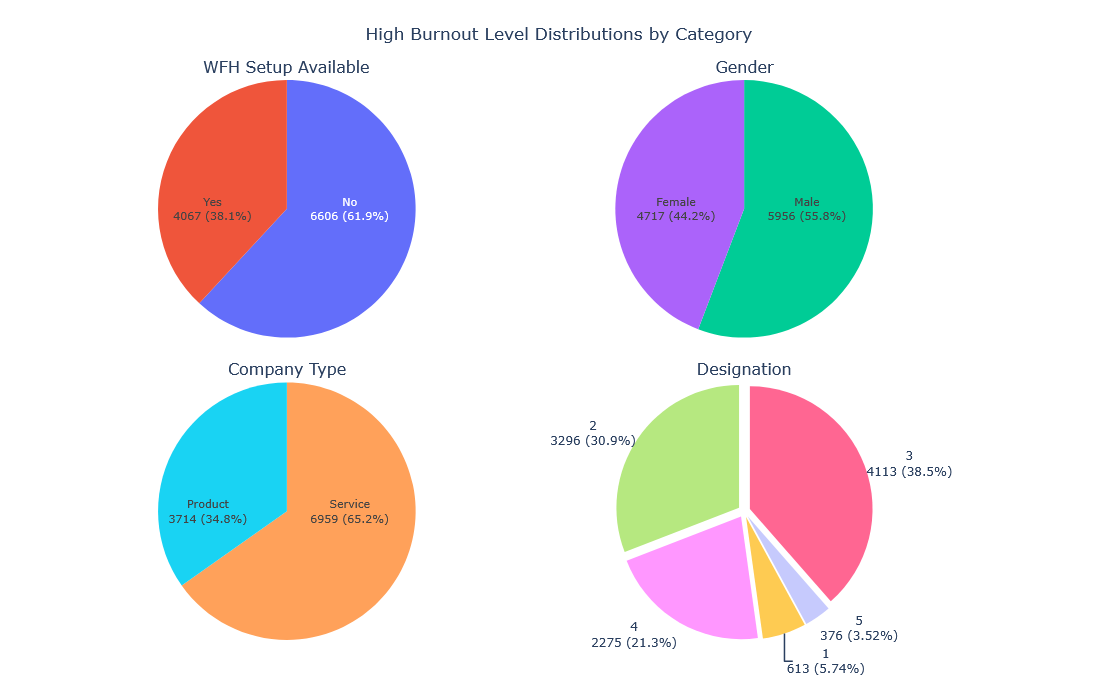

In [30]:
fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "pie"}, {"type": "pie"}],
        [{"type": "pie"}, {"type": "pie"}]
    ],
    subplot_titles=[
        "WFH Setup Available", "Gender", "Company Type", "Designation"
    ],
    horizontal_spacing=0.05,
    vertical_spacing=0.08
)
datasets = [
    (wfh_counts, "WFH Setup Available"),
    (gender_factors, "Gender"),
    (company_type_factors, "Company Type"),
    (designation_counts, "Designation")
]
positions = [(1, 1), (1, 2), (2, 1), (2, 2)]
for (df, col), (row, col_pos) in zip(datasets, positions):
    is_designation = col == "Designation"
    fig.add_trace(
        go.Pie(
            labels=df[col],
            values=df["Count"],
            texttemplate="%{label}<br>%{value} (%{percent})",
            textposition="outside" if is_designation else "inside",
            textfont=dict(size=9 if is_designation else 11),
            name=col,
            showlegend=False,
            insidetextorientation="radial" if not is_designation else None,
            pull=[0.05] * len(df) if is_designation else None 
        ),
        row=row, col=col_pos
    )
fig.update_layout(
    title=dict(
        text="High Burnout Level Distributions by Category",
        x=0.5,
        xanchor="center"
    ),
    height=700,
    width=1100,
    margin=dict(t=80, b=60, l=80, r=80), 
)
fig.update_traces(
    textfont=dict(size=12),
    selector=dict(name="Designation")
)
fig.show()

**WFH hypothesis Test**<br>
Research Question: Is there a difference in employee burn rate by Working From Home Setup?<br>
<br>
Null Hypothesis: There is no statistically significant difference in employee burn rate by Working From Home Setup<br>
<br>
Alternative Hypothesis: There is a statistically significant difference in employee burn rate by Working From Home Setup.<br>
<br>
Conclusion: There is a statistically significant difference in employee burn rate by Working From Home Setup, as the p-value of 0.0000 is below the alpha threshold of 0.05. The effect size (Cohen's d = -0.6638) is small, suggesting the difference, while statistically significant, has limited practical magnitude.<br>

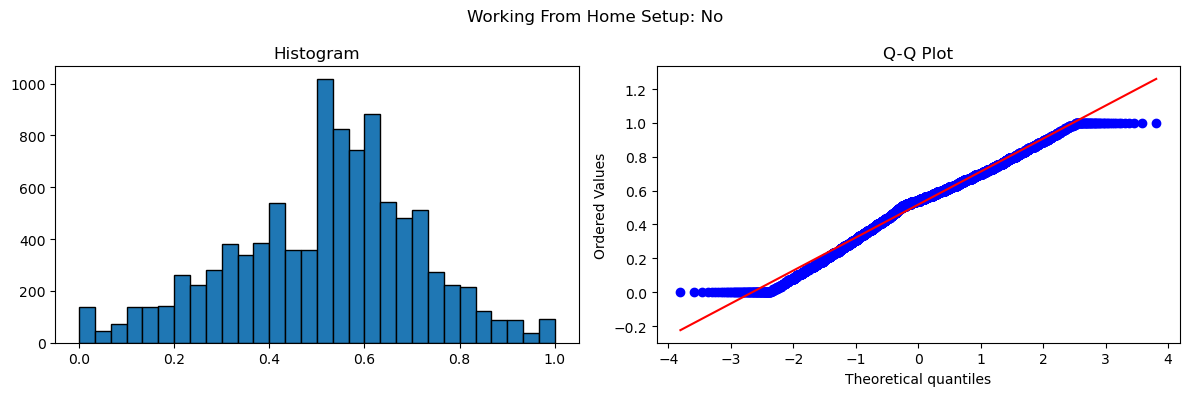

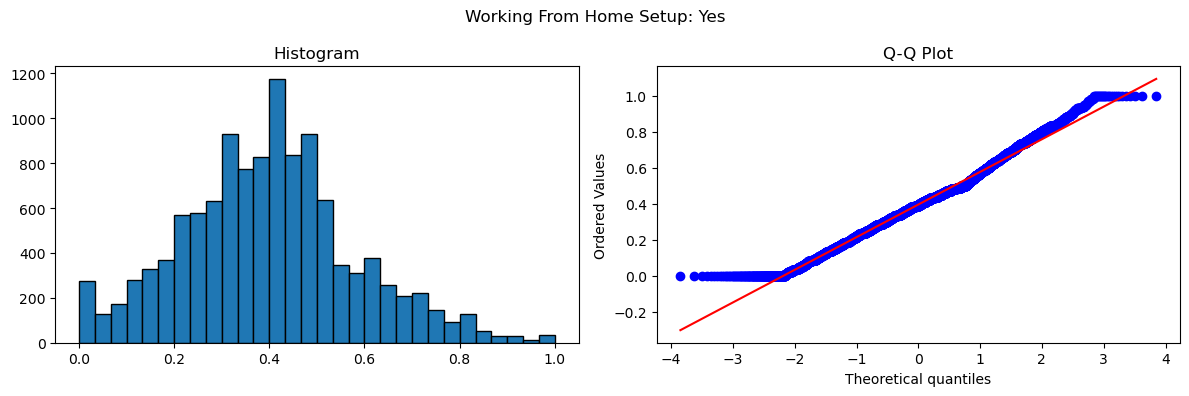

In [31]:
import scipy.stats as stats

for WFH in train["WFH Setup Available"].unique():
    subset = train[train["WFH Setup Available"] == WFH]["Burn Rate"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Working From Home Setup: {WFH}")

    axes[0].hist(subset, bins=30, edgecolor="black")
    axes[0].set_title("Histogram")

    stats.probplot(subset, plot=axes[1])
    axes[1].set_title("Q-Q Plot")

    plt.tight_layout()
    plt.show()

In [32]:
WFH_Yes = train[train["WFH Setup Available"] == "Yes"]["Burn Rate"].dropna()
WFH_No = train[train["WFH Setup Available"] == "No"]["Burn Rate"].dropna()

In [33]:
from scipy.stats import ttest_ind
stat, p = ttest_ind(WFH_Yes, WFH_No, equal_var=False)
print(f"T-Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

T-Statistic: -47.0352
P-value: 0.0000


In [34]:
alpha = 0.05
if p < alpha:
    print("Reject H₀ — Burn Rate differs significantly in Burn Rate by WFH Setup Available")
else:
    print("Fail to reject H₀ — No significant difference in Burn Rate by WFH Setup Available")

Reject H₀ — Burn Rate differs significantly in Burn Rate by WFH Setup Available


In [35]:
cohen_d = (WFH_Yes.mean() - WFH_No.mean()) / np.sqrt((WFH_Yes.std()**2 + WFH_No.std()**2) / 2)
print(f"Effect size (Cohen's d): {cohen_d:.4f}")

Effect size (Cohen's d): -0.6436


**Modeling**

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

**Baseline model**<br>
Linear regression + k fold cross validation for hyperparameter tuning

In [37]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline

In [38]:
features = [
    'Gender',
    'Company Type',
    'WFH Setup Available',
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score',
    "days_since_joined",
    "Stress Index"
]
categorical_columns = ['Gender', 'Company Type', 'WFH Setup Available']
numerical_columns = ['Designation', 'Resource Allocation', 'Mental Fatigue Score', "days_since_joined", "Stress Index"]

def evaluate_linear_regression(df, name):
    X = df[features]
    y = df['Burn Rate']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2   = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring="r2")
    cv_rmse = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error")
    cv_mae  = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring="neg_mean_absolute_error")

    return {
        "Dataset":  name,
        "CV_RMSE": -cv_rmse.mean(),
        "CV_MAE":  -cv_mae.mean(),
        "CV_R2":    cv_r2.mean(),
    }

lr_results = pd.DataFrame([
    evaluate_linear_regression(df_median, "Median Imputation"),
    evaluate_linear_regression(df_prob,   "Probabilistic Imputation")
])

print(lr_results.round(4).to_string(index=False))

                 Dataset  CV_RMSE  CV_MAE  CV_R2
       Median Imputation   0.0715  0.0538 0.8710
Probabilistic Imputation   0.0807  0.0588 0.8356


**Random Forest with and randomized search cv**

In [39]:
from sklearn.model_selection import RandomizedSearchCV

In [40]:
param_dist_rf = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5]
}

def evaluate_random_forest(df, name):
    X = df[features]
    y = df['Burn Rate']
    X_train, _, y_train, _ = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist_rf,
        n_iter=20,
        scoring={
            "RMSE": "neg_root_mean_squared_error",
            "MAE":  "neg_mean_absolute_error",
            "R2":   "r2"
        },
        refit="RMSE",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    best_idx = random_search.best_index_
    cv_results = random_search.cv_results_

    return {
        "Dataset":     name,
        "Best Params": random_search.best_params_,
        "CV_RMSE":    -cv_results["mean_test_RMSE"][best_idx],
        "CV_MAE":     -cv_results["mean_test_MAE"][best_idx],
        "CV_R2":       cv_results["mean_test_R2"][best_idx],
    }

rf_median_results = evaluate_random_forest(df_median, "Median Imputation")
rf_prob_results   = evaluate_random_forest(df_prob,   "Probabilistic Imputation")

rf_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "Best Params"}
    for r in [rf_median_results, rf_prob_results]
])

print(rf_results.round(4).to_string(index=False))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
                 Dataset  CV_RMSE  CV_MAE  CV_R2
       Median Imputation   0.0608  0.0474 0.9065
Probabilistic Imputation   0.0702  0.0522 0.8753


**Decision Tree with randomized grid search hyperparameterization**

In [41]:
from sklearn.tree import DecisionTreeRegressor

In [42]:
param_dist_dt = {
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None, 0.5],
    "model__criterion": ["squared_error", "friedman_mse", "absolute_error"]
}

def evaluate_decision_tree(df, name):
    X = df[features]
    y = df['Burn Rate']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist_dt,
        n_iter=20,
        scoring={
            "RMSE": "neg_root_mean_squared_error",
            "MAE":  "neg_mean_absolute_error",
            "R2":   "r2"
        },
        refit="RMSE",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    best_idx = random_search.best_index_
    cv_results = random_search.cv_results_

    return {
        "Dataset":     name,
        "Best Params": random_search.best_params_,
        "CV_RMSE":    -cv_results["mean_test_RMSE"][best_idx],
        "CV_MAE":     -cv_results["mean_test_MAE"][best_idx],
        "CV_R2":       cv_results["mean_test_R2"][best_idx],
    }

dt_median_results = evaluate_decision_tree(df_median, "Median Imputation")
dt_prob_results   = evaluate_decision_tree(df_prob,   "Probabilistic Imputation")

dt_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "Best Params"}
    for r in [dt_median_results, dt_prob_results]
])

print(dt_results.round(4).to_string(index=False))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
                 Dataset  CV_RMSE  CV_MAE  CV_R2
       Median Imputation   0.0638  0.0496 0.8970
Probabilistic Imputation   0.0768  0.0557 0.8509


**LightGBM with feature engineering with randomized grid search hyper parameterization**

In [43]:
from sklearn import set_config
set_config(transform_output="pandas")

param_dist_lgb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [-1, 5, 10, 20],
    "model__num_leaves": [15, 31, 63, 127],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 2, 5, 10]
}

def evaluate_lightgbm(df, name):
    X = df[features]
    y = df['Burn Rate']
    X_train, _, y_train, _ = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", lgb.LGBMRegressor(random_state=42, verbose=-1))
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist_lgb,
        n_iter=20,
        scoring={
            "RMSE": "neg_root_mean_squared_error",
            "MAE":  "neg_mean_absolute_error",
            "R2":   "r2"
        },
        refit="RMSE",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    best_idx = random_search.best_index_
    cv_results = random_search.cv_results_

    return {
        "Dataset":     name,
        "Best Params": random_search.best_params_,
        "CV_RMSE":    -cv_results["mean_test_RMSE"][best_idx],
        "CV_MAE":     -cv_results["mean_test_MAE"][best_idx],
        "CV_R2":       cv_results["mean_test_R2"][best_idx],
    }

lgb_median_results = evaluate_lightgbm(df_median, "Median Imputation")
lgb_prob_results   = evaluate_lightgbm(df_prob,   "Probabilistic Imputation")

lgb_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "Best Params"}
    for r in [lgb_median_results, lgb_prob_results]
])

print(lgb_results.round(4).to_string(index=False))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
                 Dataset  CV_RMSE  CV_MAE  CV_R2
       Median Imputation   0.0607  0.0475 0.9070
Probabilistic Imputation   0.0703  0.0525 0.8749


**Gradient Boosting Regressor with randomized grid search hyperparamterization**

In [44]:
from sklearn import ensemble
from sklearn.ensemble import GradientBoostingRegressor

In [45]:
param_dist_gb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__max_features": ["sqrt", "log2", None, 0.5]
}

def evaluate_gradient_boosting(df, name):
    X = df[features]
    y = df['Burn Rate']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            loss="squared_error",
            random_state=42
        ))
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist_gb,
        n_iter=20,
        scoring={
            "RMSE": "neg_root_mean_squared_error",
            "MAE":  "neg_mean_absolute_error",
            "R2":   "r2"
        },
        refit="RMSE",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    best_idx = random_search.best_index_
    cv_results = random_search.cv_results_

    return {
        "Dataset":     name,
        "Best Params": random_search.best_params_,
        "CV_RMSE":    -cv_results["mean_test_RMSE"][best_idx],
        "CV_MAE":     -cv_results["mean_test_MAE"][best_idx],
        "CV_R2":       cv_results["mean_test_R2"][best_idx],
    }

gb_median_results = evaluate_gradient_boosting(df_median, "Median Imputation")
gb_prob_results   = evaluate_gradient_boosting(df_prob,   "Probabilistic Imputation")

gb_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "Best Params"}
    for r in [gb_median_results, gb_prob_results]
])

print(gb_results.round(4).to_string(index=False))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
                 Dataset  CV_RMSE  CV_MAE  CV_R2
       Median Imputation   0.0609  0.0476 0.9064
Probabilistic Imputation   0.0699  0.0522 0.8766


**XgBoost**

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [47]:
!nvidia-smi

Mon Jun  1 14:14:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.49                 Driver Version: 596.49         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   52C    P8             19W /  129W |     500MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [48]:
param_dist_xgb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 2, 5, 10]
}

def evaluate_xgboost(df, name):
    X = df[features]
    y = df['Burn Rate']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )
    
    pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42
    ))
])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist_xgb,
        n_iter=20,
        scoring={
            "RMSE": "neg_root_mean_squared_error",
            "MAE":  "neg_mean_absolute_error",
            "R2":   "r2"
        },
        refit="RMSE",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=1
    )
    random_search.fit(X_train, y_train)

    best_idx = random_search.best_index_
    cv_results = random_search.cv_results_

    return {
        "Dataset":     name,
        "Best Params": random_search.best_params_,
        "CV_RMSE":    -cv_results["mean_test_RMSE"][best_idx],
        "CV_MAE":     -cv_results["mean_test_MAE"][best_idx],
        "CV_R2":       cv_results["mean_test_R2"][best_idx],
    }

xgb_median_results = evaluate_xgboost(df_median, "Median Imputation")
xgb_prob_results   = evaluate_xgboost(df_prob,   "Probabilistic Imputation")

xgb_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "Best Params"}
    for r in [xgb_median_results, xgb_prob_results]
])

print(xgb_results.round(4).to_string(index=False))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
                 Dataset  CV_RMSE  CV_MAE  CV_R2
       Median Imputation   0.0608  0.0475 0.9066
Probabilistic Imputation   0.0696  0.0519 0.8776


**Regression Model comparision**

In [49]:
all_model_results = pd.concat([
    lr_results.assign(Model="Linear Regression"),
    rf_results.assign(Model="Random Forest"),
    dt_results.assign(Model="Decision Tree"),
    gb_results.assign(Model="Gradient Boosting"),
    lgb_results.assign(Model="LightGBM"),
    xgb_results.assign(Model="XGBoost"),
], ignore_index=True)

all_model_results = all_model_results[["Model", "Dataset", "CV_RMSE", "CV_MAE", "CV_R2"]]

print(all_model_results.round(4).to_string(index=False))

            Model                  Dataset  CV_RMSE  CV_MAE  CV_R2
Linear Regression        Median Imputation   0.0715  0.0538 0.8710
Linear Regression Probabilistic Imputation   0.0807  0.0588 0.8356
    Random Forest        Median Imputation   0.0608  0.0474 0.9065
    Random Forest Probabilistic Imputation   0.0702  0.0522 0.8753
    Decision Tree        Median Imputation   0.0638  0.0496 0.8970
    Decision Tree Probabilistic Imputation   0.0768  0.0557 0.8509
Gradient Boosting        Median Imputation   0.0609  0.0476 0.9064
Gradient Boosting Probabilistic Imputation   0.0699  0.0522 0.8766
         LightGBM        Median Imputation   0.0607  0.0475 0.9070
         LightGBM Probabilistic Imputation   0.0703  0.0525 0.8749
          XGBoost        Median Imputation   0.0608  0.0475 0.9066
          XGBoost Probabilistic Imputation   0.0696  0.0519 0.8776


**Which model performs the best for median imputation and probabilistic imputation?**
- Every Model yields a higher R2 score than the Baseline Linear Regression Model
- For the median dataset, the lightGBM model performs the best, followed by XGBoost and Random Forest
- For the probabilistic dataset, the XGBoost model performs the best, followed by gradient boosting and random forest 

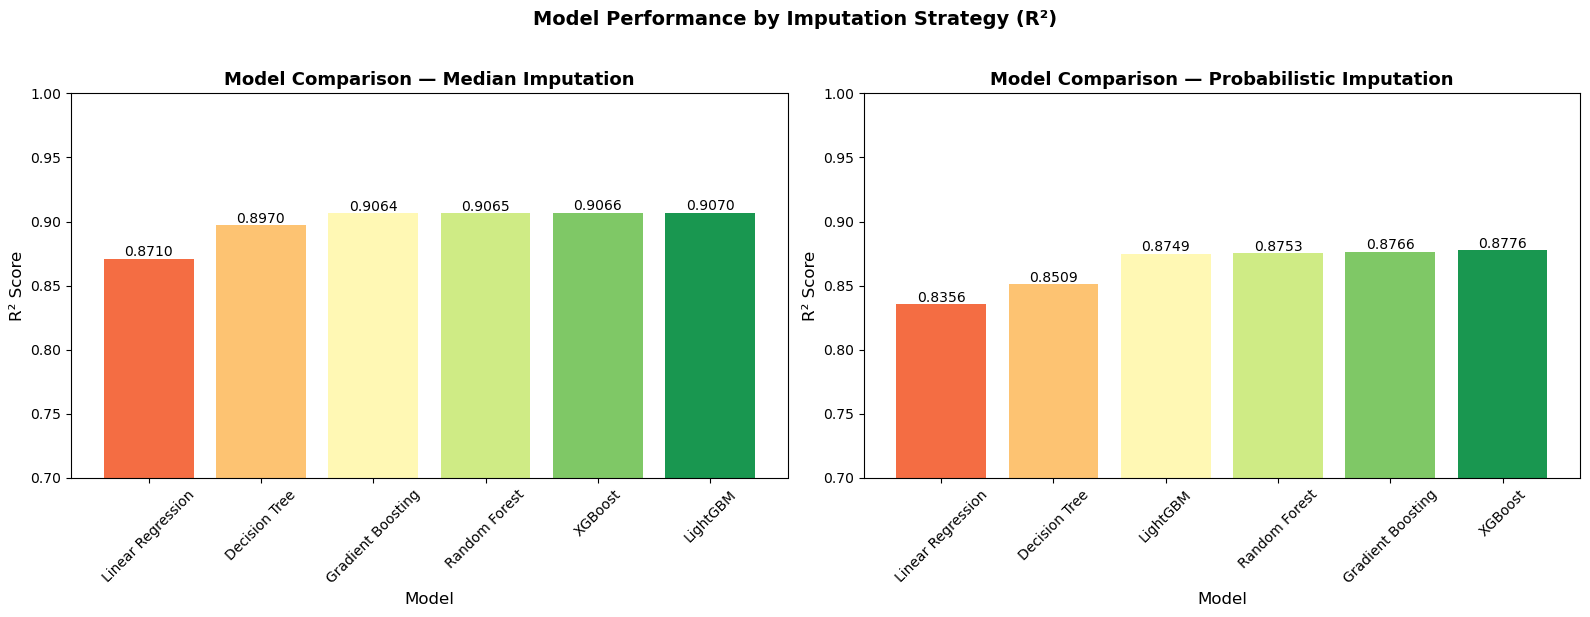

In [50]:
median_results = all_model_results[all_model_results["Dataset"] == "Median Imputation"].sort_values("CV_R2", ascending=True)
prob_results = all_model_results[all_model_results["Dataset"] == "Probabilistic Imputation"].sort_values("CV_R2", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(median_results)))

bars1 = axes[0].bar(median_results["Model"], median_results["CV_R2"], color=colors)
axes[0].set_ylabel("R² Score", fontsize=12)
axes[0].set_xlabel("Model", fontsize=12)
axes[0].set_title("Model Comparison — Median Imputation", fontsize=13, fontweight="bold")
axes[0].set_ylim(0.70, 1.0)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, median_results["CV_R2"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.4f}", ha="center", fontsize=10)

prob_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(prob_results)))
bars2 = axes[1].bar(prob_results["Model"], prob_results["CV_R2"], color=prob_colors)
axes[1].set_ylabel("R² Score", fontsize=12)
axes[1].set_xlabel("Model", fontsize=12)
axes[1].set_title("Model Comparison — Probabilistic Imputation", fontsize=13, fontweight="bold")
axes[1].set_ylim(0.70, 1.0)
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, prob_results["CV_R2"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.4f}", ha="center", fontsize=10)

plt.suptitle("Model Performance by Imputation Strategy (R²)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison_r2.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretable K means clustering**

In [51]:
# 1. Install Cython if not already present (usually is)
!pip install cython numpy

# 2. Clone the official repository
!git clone https://github.com/navefr/ExKMC.git

# 3. Move into the splitters directory and recompile the .pyx file
%cd ExKMC/ExKMC/splitters/
!cython cut_finder.pyx

# 4. Move back to the root and install
%cd ../..
!python setup.py install

%cd /content

import sys
import os

# This points to where your log said it installed the .egg
sys.path.append('/usr/local/lib/python3.12/dist-packages/ExKMC-0.0.3-py3.12-linux-x86_64.egg')

import graphviz
import re
from IPython.display import SVG, display
from ExKMC.Tree import Tree

C:\Users\alexh\Python\DSC 288 Capstone Project\Final Dataset and Notebook\ExKMC\ExKMC\splitters


fatal: destination path 'ExKMC' already exists and is not an empty directory.


C:\Users\alexh\Python\DSC 288 Capstone Project\Final Dataset and Notebook\ExKMC


performance hint: cut_finder.pyx:84:0: Exception check on 'update_col_min_mistakes_cut' will always require the GIL to be acquired.
Possible solutions:
	1. Declare 'update_col_min_mistakes_cut' as 'noexcept' if you control the definition and you're sure you don't want the function to raise exceptions.
	2. Use an 'int' return type on 'update_col_min_mistakes_cut' to allow an error code to be returned.
performance hint: cut_finder.pyx:297:0: Exception check on 'update_col_surrogate_cut' will always require the GIL to be acquired.
Possible solutions:
	1. Declare 'update_col_surrogate_cut' as 'noexcept' if you control the definition and you're sure you don't want the function to raise exceptions.
	2. Use an 'int' return type on 'update_col_surrogate_cut' to allow an error code to be returned.
performance hint: cut_finder.pyx:59:43: Exception check after calling 'update_col_min_mistakes_cut' will always require the GIL to be acquired.
Possible solutions:
	1. Declare 'update_col_min_mistakes

running install
running build
running build_py
copying ExKMC\Tree.py -> build\lib.win-amd64-cpython-312\ExKMC
copying ExKMC\__init__.py -> build\lib.win-amd64-cpython-312\ExKMC
copying ExKMC\splitters\setup.py -> build\lib.win-amd64-cpython-312\ExKMC\splitters
copying ExKMC\splitters\__init__.py -> build\lib.win-amd64-cpython-312\ExKMC\splitters
running build_ext
building 'cut_finder' extension
"C:\Program Files\Microsoft Visual Studio\2022\Community\VC\Tools\MSVC\14.43.34808\bin\HostX86\x64\cl.exe" /c /nologo /O2 /W3 /GL /DNDEBUG /MD -IC:\Users\alexh\anaconda3\Lib\site-packages\numpy\_core\include -IC:\Users\alexh\anaconda3\include -IC:\Users\alexh\anaconda3\Include "-IC:\Program Files\Microsoft Visual Studio\2022\Community\VC\Tools\MSVC\14.43.34808\include" "-IC:\Program Files\Microsoft Visual Studio\2022\Community\VC\Tools\MSVC\14.43.34808\ATLMFC\include" "-IC:\Program Files\Microsoft Visual Studio\2022\Community\VC\Auxiliary\VS\include" "-IC:\Program Files (x86)\Windows Kits\10\inc

C:\Users\alexh\anaconda3\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'liceanse'
  warnings.warn(msg)
C:\Users\alexh\anaconda3\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
!!

        ********************************************************************************
        Please consider removing the following classifiers in favor of a SPDX license expression:

        License :: OSI Approved :: MIT License

        See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
        ********************************************************************************

!!
  self._finalize_license_expression()
C:\Users\alexh\anaconda3\Lib\site-packages\setuptools\_distutils\cmd.py:90: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Pl

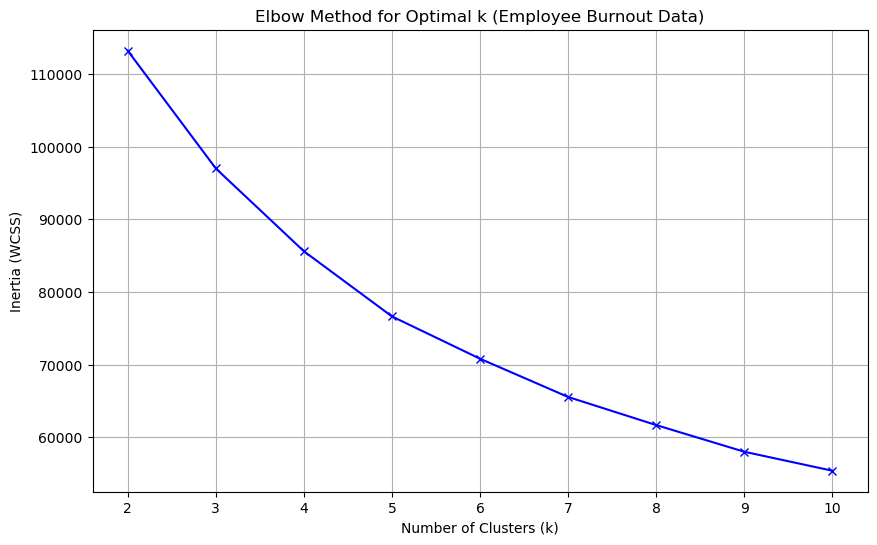

In [52]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df_k = df_prob.copy()
# 1. Prepare features for clustering
# We exclude 'Burn Rate' from the clustering itself so we can use it to validate the clusters later
df_k["gender"] = df_prob["Gender"].map({"Male": 1, "Female": 0})
df_k["company_type"] = df_prob["Company Type"].map({"Service": 1, "Product": 0})
df_k["is_wfh"] = df_prob["WFH Setup Available"].map({"Yes": 1, "No": 0})
df_k = df_k.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

cluster_features = [col for col in df_k.columns if col not in ['Burn Rate']]

# Continuous columns to scale
scale_cols = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined",
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "Stress Index"
]

scaler_prob = StandardScaler()
df_k[scale_cols] = scaler_prob.fit_transform(df_k[scale_cols])

X_elbow = df_k[cluster_features]

# 2. Run Elbow Test
wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_elbow)
    wcss.append(kmeans.inertia_)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k (Employee Burnout Data)')
plt.grid(True)
plt.show()

In [53]:
import graphviz


Visualizing Employee Burnout Personas (k=4, max_leaves=8):


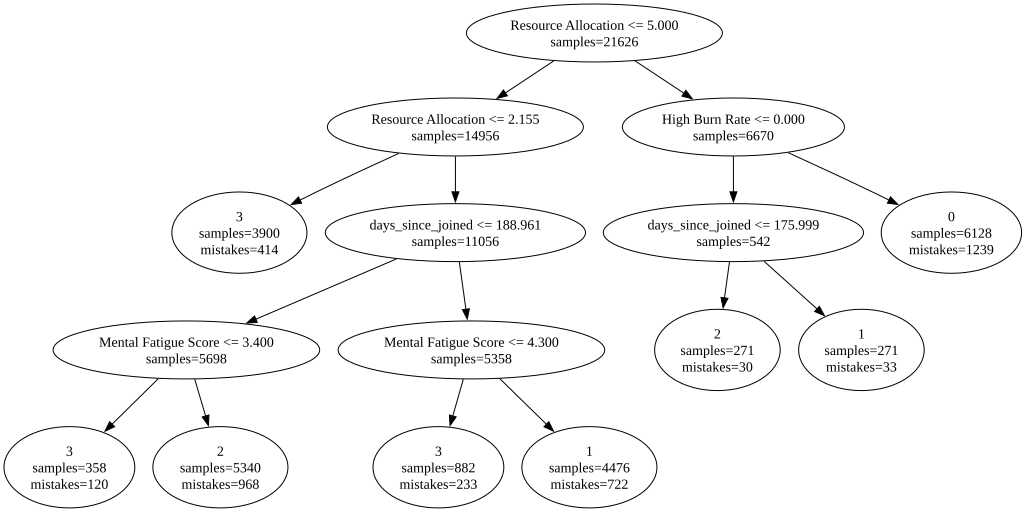


--- Employee Burnout Persona Report ---


,Avg_Burn_Rate,Avg_Fatigue_Score,Avg_Resources,Avg_Designation,Avg_Days_Joined,WFH_Percent,Percent_Male,Employee_Count
burnout_cluster,,,,,,,,
0.0,0.663703,7.410656,6.968668,3.350033,181.082409,32.0%,58.7%,6128
1.0,0.449831,5.953023,4.286497,2.074784,277.781336,58.7%,44.8%,4747
2.0,0.432208,5.738050,4.204242,2.049724,95.797006,60.2%,44.6%,5611
3.0,0.223235,3.520856,2.021984,1.019261,191.424319,69.2%,39.9%,5140


In [54]:
# 1. Configuration
k_optimal = 4

# Add the engineered interaction terms to the forbidden list
engineered_cols = [
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "High Workload",
    "High Fatigue",
    "Stress Index"
]
forbidden_cols = ['Burn Rate', 'burnout_cluster', 'Employee ID'] + engineered_cols

all_features = [col for col in df_k.columns if col not in forbidden_cols]

X_final = df_k[all_features].values

# 2. Fit ExKMC
model_tree = Tree(k=k_optimal, max_leaves=8, random_state=42)
model_tree.fit(X_final)

# 3. Generate Labels
df_k['burnout_cluster'] = model_tree.predict(X_final)

# 4. Explainable Plotting with Inverse Scaling
gv_file = 'burnout_tree.gv'
try:
    model_tree.plot('burnout_tree', feature_names=all_features, view=False)

    with open(gv_file, 'r') as f:
        dot_data = f.read()

    def inverse_transform_burnout(match):
        feature, threshold = match.group(1).strip(), float(match.group(2))
        # Ensure we only try to scale columns that were originally part of scale_cols
        if feature in scale_cols:
            idx = scale_cols.index(feature)
            original_val = (threshold * np.sqrt(scaler_prob.var_[idx])) + scaler_prob.mean_[idx]
            return f'{feature} <= {original_val:.3f}'
        return match.group(0)

    readable_dot_data = re.sub(r'([\w_ ]+) <= ([-+]?\d*\.\d+|\d+)', inverse_transform_burnout, dot_data)

    print(f"\nVisualizing Employee Burnout Personas (k={k_optimal}, max_leaves=8):")
    s = graphviz.Source(readable_dot_data, filename="burnout_tree_final", format="svg")
    display(SVG(s.render(cleanup=True)))

except Exception as e:
    print(f"Visualization failed: {e}")

# 5. Burnout Persona Summary
print("\n--- Employee Burnout Persona Report ---")

df_report = df_k.copy()
# Only unscale columns that are still in our reporting set
for col in [c for c in scale_cols if c in df_report.columns]:
    idx = scale_cols.index(col)
    df_report[col] = (df_k[col] * np.sqrt(scaler_prob.var_[idx])) + scaler_prob.mean_[idx]

summary = df_report.groupby('burnout_cluster').agg({
    'Burn Rate': 'mean',
    'Mental Fatigue Score': 'mean',
    'Resource Allocation': 'mean',
    'Designation': 'mean',
    'days_since_joined': 'mean',
    'is_wfh': 'mean',
    'gender': ['mean', 'count']
})

# 6. Clean up Column Names
summary.columns = [
    'Avg_Burn_Rate',
    'Avg_Fatigue_Score',
    'Avg_Resources',
    'Avg_Designation',
    'Avg_Days_Joined',
    'WFH_Percent',
    'Percent_Male',
    'Employee_Count'
]

# 7. Format for readability
summary['WFH_Percent'] = (summary['WFH_Percent'] * 100).round(1).astype(str) + '%'
summary['Percent_Male'] = (summary['Percent_Male'] * 100).round(1).astype(str) + '%'

display(summary.sort_values(by='Avg_Burn_Rate', ascending=False))

Cluster 3: The High-Load "At-Risk" Segment<br>
This cluster is found via three different paths, but they all share a common theme of high pressure.The Primary Group: Employees with Resource Allocation > 6.0. This is the tree's very first split, indicating that extreme workload is the #1 identifier for this persona.The "Tenured Under-Performer": Employees with moderate resources (between 2 and 6) but who have been with the company a long time (> 185 days) and have a high designation (> 3.0).Persona: These are your "Workhorses." They are likely the most senior people carrying the heaviest project loads.<br>
Cluster 2:  The Low-Resource "Quiet" Group<br>
The Path: Low Resource Allocation ($\le$ 1.9) AND Low Fatigue ($\le$ 6.8).Persona: These employees have manageable workloads and healthy mental fatigue scores. They represent the "Safe Zone" of your organization where burn rate is likely at its lowest.<br>
Cluster 1:The "Fatigued Newbies"<br>
The Path: Moderate resources (2 to 6) but very high Mental Fatigue (> 6.8). Another significant group shows up for those with low tenure ($\le$ 185 days) who have moderate fatigue (> 3.2).Persona: This is a "Warning" segment. Even if their actual resource count isn't the highest, their subjective fatigue is high. The tenure split suggests that newer employees might be struggling with the learning curve or lack of support, leading to fatigue even without "extreme" workloads.<br>
Cluster 0: The "Mid-Tier Managers"<br>
The Path: Moderate resources (2 to 6), long tenure (> 185 days), but a lower designation ($\le$ 3.0).Persona: These are your established, mid-level staff. They have survived the initial "newbie" phase and haven't yet been promoted into the high-stress, high-resource "Cluster 3" roles. They are the stable core of the workforce.

Key Takeaways from the 8-Leaf Expansion<br>
1. Resource Allocation is the King Split: The model immediately separates the "Extreme Workload" (Cluster 3) from everyone else.<br>

2. The "185-Day" Milestone: The tree reveals that tenure significantly changes how employees experience their workload. Employees who have been around for more than 6 months are processed through a different logic (Designation) than those who are newer.<br>

3. Redundancy for Accuracy: Notice how Cluster 1 and Cluster 3 appear in multiple leaves. This is ExKMC doing its job—it's using multiple "rectangles" to more accurately capture the shape of those burnout personas than a simple 4-leaf tree ever could.<br>